In [1]:
import sys
from pathlib import Path

# Path to the parent folder (where util is)
parent_path = Path().resolve().parent.parent
sys.path.append(str(parent_path))
import util
import plotting.plotting_style as plt
import pandas as pd
import numpy as np
#import matplotlib.pyplot as plt
import seaborn as sns
import help_functions as hp
#import tueplots as tue
from plotting.plotting_style import rgb

plt.bundles.icml2024(column="full")

data = util.load_data(path_file='/Users/maxwernz/development/Data Literacy/data_csv/final_Data_iaaf_scores_neu_v2.csv') 

# data  = util.load_data()
data.head()

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score,group
0,2017,W,Frauen,100 m,10.95,1.3,Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211,Sprint
1,2017,W,Frauen,100 m,11.06,1.8,Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda,1187,Sprint
2,2017,W,Frauen,100 m,11.14,-0.2,Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169,Sprint
3,2017,W,Frauen,100 m,11.24,0.3,Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL,1148,Sprint
4,2017,W,Frauen,100 m,11.25,1.9,Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg,1146,Sprint


In [2]:
# Define Adult age group
data['altersklasse'] = data['altersklasse'].replace({'Maenner': 'Adult', 'Frauen': 'Adult', '18': 'U18', '20': 'U20'})

In [3]:

summary = data.groupby(['jahr', 'altersklasse', 'geschlecht', 'disziplin']).size().reset_index(name='anzahl')
under = summary[(summary['altersklasse'] == 'U23') | (summary['anzahl'] < 35)]
under = under.sort_values(by=['jahr', 'altersklasse', 'geschlecht', 'disziplin'])


data_all = data.groupby(['jahr', 'altersklasse', 'geschlecht', 'disziplin']).filter(lambda x: x.name[1] != 'U23' and len(x) >= 35)

In [4]:
data_all = data_all.sort_values(by='iaaf_score', ascending=False) # Sicherstellen, dass die Besten oben stehen
data_all = data_all.groupby(['jahr', 'altersklasse', 'geschlecht', 'disziplin']).head(35)

In [5]:
from scipy import stats

def get_anaysis_data(df, group_cols, start_period=(2001, 2005), end_period=(2021, 2025)):
    results = []
    
    grouped = df.groupby(group_cols) if group_cols else [("Global", df)]

    for names, subgroup in grouped:

        def get_period_pool(data, years):
            period_data = data[data["jahr"].between(*years)]
            
            top_12_pool = (period_data.groupby("jahr")["iaaf_score"].nlargest(3).reset_index(drop=True))
            
            low_12_pool = (period_data.groupby("jahr")["iaaf_score"].nsmallest(3).reset_index(drop=True))
            
            return top_12_pool, low_12_pool

        s_top, s_low = get_period_pool(subgroup, start_period)
        e_top, e_low = get_period_pool(subgroup, end_period)

        s_pool = subgroup[subgroup["jahr"].between(*start_period)]["iaaf_score"].dropna()
        e_pool = subgroup[subgroup["jahr"].between(*end_period)]["iaaf_score"].dropna()

        if len(s_top) > 1 and len(e_top) > 1 and len(s_low) > 1 and len(e_low) > 1:
            # Mann-Whitney-U-Test for median comparison
            u_stat, p_median = stats.mannwhitneyu(e_pool, s_pool, alternative='two-sided')

            # Medians
            med_e, med_s = np.median(e_pool), np.median(s_pool)

            # Effect size r
            n_total = len(e_pool) + len(s_pool)
            z_score = stats.norm.ppf(p_median / 2) # approximation
            r_effect = abs(z_score) / np.sqrt(n_total)

            m_diff_perc = (med_e - med_s) / med_s * 100

            gap_s = s_top.mean() - s_low.mean()
            gap_e = e_top.mean() - e_low.mean()

            top_3_avg_s = s_top.mean()
            low_3_avg_s = s_low.mean()
            top_3_avg_e = e_top.mean()
            low_3_avg_e = e_low.mean()

            obs_diff = gap_e - gap_s

            boot_diffs = []
            for _ in range(1000):
                # Resampling mit Zurücklegen innerhalb der 12er Gruppen
                s_top_res = np.random.choice(s_top, size=len(s_top), replace=True).mean()
                s_low_res = np.random.choice(s_low, size=len(s_low), replace=True).mean()
                e_top_res = np.random.choice(e_top, size=len(e_top), replace=True).mean()
                e_low_res = np.random.choice(e_low, size=len(e_low), replace=True).mean()
                
                boot_diffs.append((e_top_res - e_low_res) - (s_top_res - s_low_res))
            
            boot_diffs = np.array(boot_diffs)
            ci_low = np.percentile(boot_diffs, 2.5)
            ci_high = np.percentile(boot_diffs, 97.5)

            std_boot = np.std(boot_diffs)
            effect_size_d = obs_diff / std_boot if std_boot != 0 else 0
            
            # P-Wert für den Gap (zweiseitig)
            p_gap = np.mean(np.abs(boot_diffs - np.mean(boot_diffs)) >= np.abs(obs_diff))

            # Gap difference percentage
            gap_diff_perc = ((gap_e - gap_s) / gap_s * 100) if gap_s > 0 else 0

            res = {col: val for col, val in zip(group_cols, names)} if group_cols else {"Group": "Global"}
            res.update({
                "Median_Start": round(med_s, 2),
                "Median_End": round(med_e, 2),
                "Median_Diff_Abs": round((med_e - med_s), 2),
                "Median_Diff_%": round(m_diff_perc, 2),
                "P_Val_MWU": round(p_median, 4),
                "MWU_sig": "Yes" if p_median < 0.05 else "No",
                "Effect_r": round(r_effect, 3),
                "Gap_Start": round(gap_s, 2),
                "Gap_Start_top3_avg": round(top_3_avg_s, 2),
                "Gap_Start_low3_avg": round(low_3_avg_s, 2),
                "Gap_End": round(gap_e, 2),
                "Gap_End_top3_avg": round(top_3_avg_e, 2),
                "Gap_End_low3_avg": round(low_3_avg_e, 2),
                "Gap_Diff_Abs": round(obs_diff, 2),
                "Gap_Diff_%": round(gap_diff_perc, 2),
                "Gap_CI_Lower": round(ci_low, 2),
                "Gap_CI_Upper": round(ci_high, 2),
                "Gap_Sig_Bootstrap": "Yes" if ci_low > 0 or ci_high < 0 else "No",
                "Gap_Effect_Size": round(effect_size_d, 3),
            })
            results.append(res)

    return pd.DataFrame(results)

analysis_results = get_anaysis_data(data_all, group_cols=['altersklasse', 'geschlecht', 'disziplin'])
analysis_results.head()

,altersklasse,geschlecht,disziplin,Median_Start,Median_End,Median_Diff_Abs,Median_Diff_%,P_Val_MWU,MWU_sig,Effect_r,...,Gap_Start_low3_avg,Gap_End,Gap_End_top3_avg,Gap_End_low3_avg,Gap_Diff_Abs,Gap_Diff_%,Gap_CI_Lower,Gap_CI_Upper,Gap_Sig_Bootstrap,Gap_Effect_Size
0,Adult,M,10 000 m,896.0,961.0,65.0,7.25,0.0,Yes,0.347,...,847.73,277.53,1140.60,863.07,86.40,45.20,55.26,118.88,Yes,5.340
1,Adult,M,10 km,942.0,991.0,49.0,5.20,0.0,Yes,0.427,...,899.80,165.58,1107.00,941.42,25.45,18.16,3.98,46.50,Yes,2.329
2,Adult,M,100 m,1008.0,1076.0,68.0,6.75,0.0,Yes,0.602,...,968.80,140.87,1175.73,1034.87,-11.67,-7.65,-26.87,3.87,No,-1.521
3,Adult,M,110 m Huerden,1012.0,979.0,-33.0,-3.26,0.0,Yes,0.306,...,946.73,225.73,1128.00,902.27,26.60,13.36,8.73,44.88,Yes,2.912
4,Adult,M,1500 m,1029.0,1062.0,33.0,3.21,0.0,Yes,0.368,...,984.40,166.87,1180.00,1013.13,27.87,20.05,8.53,46.34,Yes,2.881


In [6]:
analysis_results

,altersklasse,geschlecht,disziplin,Median_Start,Median_End,Median_Diff_Abs,Median_Diff_%,P_Val_MWU,MWU_sig,Effect_r,...,Gap_Start_low3_avg,Gap_End,Gap_End_top3_avg,Gap_End_low3_avg,Gap_Diff_Abs,Gap_Diff_%,Gap_CI_Lower,Gap_CI_Upper,Gap_Sig_Bootstrap,Gap_Effect_Size
0,Adult,M,10 000 m,896.0,961.0,65.0,7.25,0.0000,Yes,0.347,...,847.73,277.53,1140.60,863.07,86.40,45.20,55.26,118.88,Yes,5.340
1,Adult,M,10 km,942.0,991.0,49.0,5.20,0.0000,Yes,0.427,...,899.80,165.58,1107.00,941.42,25.45,18.16,3.98,46.50,Yes,2.329
2,Adult,M,100 m,1008.0,1076.0,68.0,6.75,0.0000,Yes,0.602,...,968.80,140.87,1175.73,1034.87,-11.67,-7.65,-26.87,3.87,No,-1.521
3,Adult,M,110 m Huerden,1012.0,979.0,-33.0,-3.26,0.0000,Yes,0.306,...,946.73,225.73,1128.00,902.27,26.60,13.36,8.73,44.88,Yes,2.912
4,Adult,M,1500 m,1029.0,1062.0,33.0,3.21,0.0000,Yes,0.368,...,984.40,166.87,1180.00,1013.13,27.87,20.05,8.53,46.34,Yes,2.881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,U20,W,Hochsprung,975.0,945.0,-30.0,-3.08,0.0000,Yes,0.336,...,939.47,156.67,1070.07,913.40,19.67,14.36,-2.47,43.20,No,1.660
102,U20,W,Kugelstoss,766.0,731.0,-35.0,-4.57,0.0000,Yes,0.358,...,729.87,265.33,942.60,677.27,35.80,15.60,5.19,68.20,Yes,2.195
103,U20,W,Speerwurf,807.0,753.0,-54.0,-6.69,0.0000,Yes,0.399,...,760.47,257.07,947.87,690.80,29.87,13.15,-8.34,65.14,No,1.576
104,U20,W,Stabhochsprung,838.0,838.0,0.0,0.00,0.9153,No,0.006,...,767.40,248.47,1012.87,764.40,-1.80,-0.72,-38.68,29.20,No,-0.101


In [7]:
mapping_dict = {
    **{d: 'Run' for d in ['800 m', '1500 m', '3000 m', '5000 m', '10 000 m', '10 km', 'Marathon', '2000 m Hindernis', '3000 m Hindernis']},
    **{d: 'Sprint' for d in ['100 m', '200 m', '400 m', '100 m  Huerden', '110 m Huerden', '400 m Huerden']},
    **{d: 'Throw' for d in ['Kugelstoss', 'Diskuswurf', 'Speerwurf', 'Hammerwurf']}, 
    **{d: 'Jump' for d in ['Hochsprung', 'Stabhochsprung', 'Weitsprung', 'Dreisprung']},
    **{d: 'Combined' for d in ['Zehnkampf', 'Siebenkampf']}
}

analysis_results['group'] = analysis_results['disziplin'].map(mapping_dict)

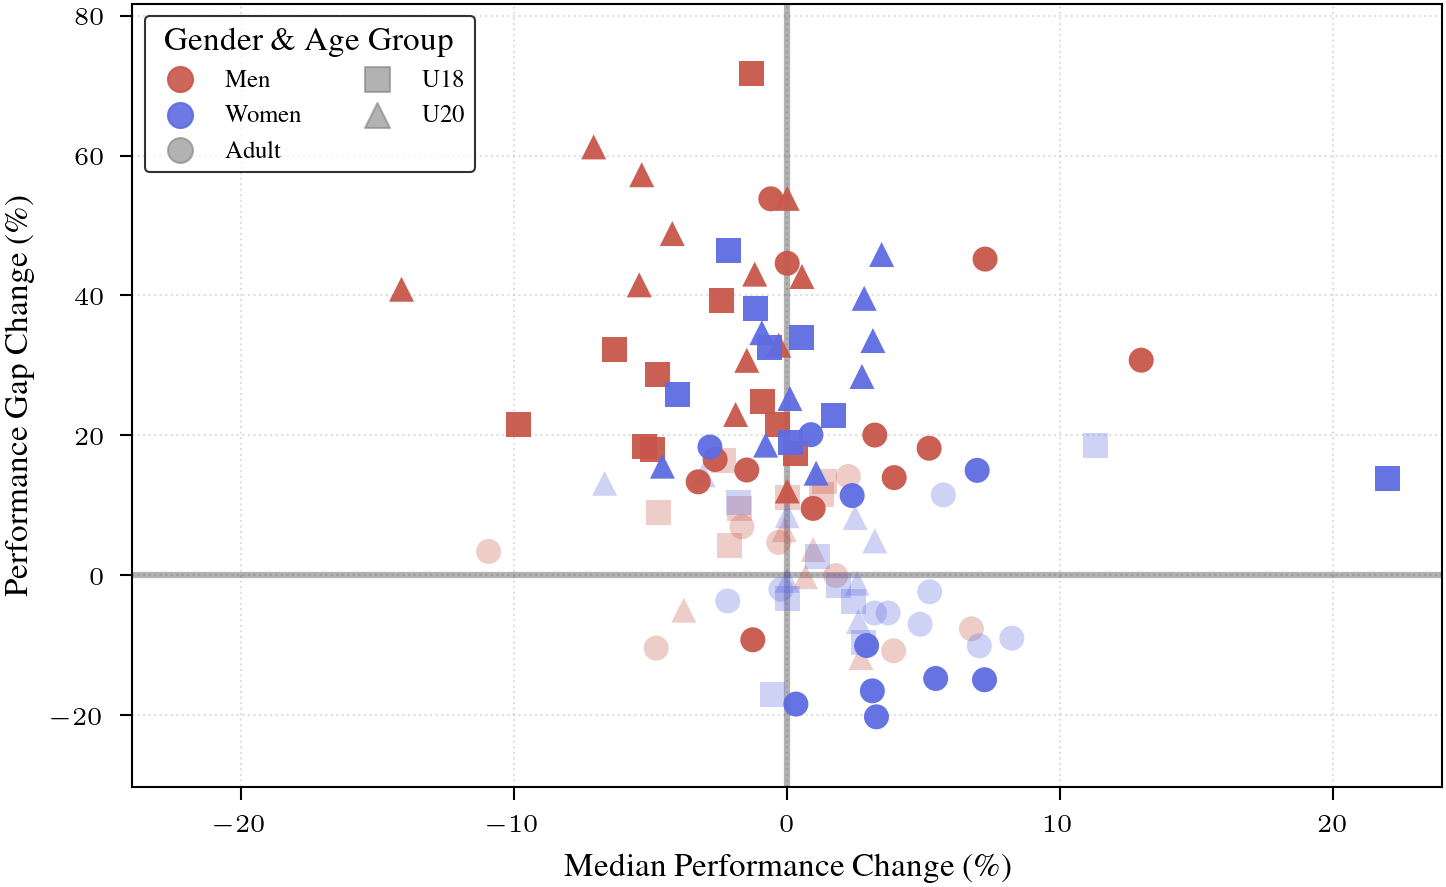

In [24]:
# import matplotlib.pyplot as plt

# 1. Prepare Data
plot_data = analysis_results.copy()

# 2. Initialize Plot
with plt.rc_context(plt.increase_figsize(1.5)):
    fig, ax = plt.subplots()

    # 3. Define Aesthetics
    colors = {'M': "#c8564a", 'W': "#5e6be1"} 
    labels = {'M': 'Men', 'W': 'Women'}

    # Marker-Mapping für Altersklassen (Beispielhaft für 3 Klassen)
    # 'o' = Kreis, 's' = Quadrat, '^' = Dreieck
    unique_ages = sorted(plot_data['altersklasse'].unique())
    marker_styles = ['o', 's', '^', 'D', 'v'] # Liste an Stilen
    marker_map = {age: marker_styles[i] for i, age in enumerate(unique_ages)}

    # 4. Scatter Plot
    for gender in ['M', 'W']:
        if gender not in plot_data['geschlecht'].unique():
            continue

        
        
        # Legend Proxy für Geschlecht (Farbe)
        ax.scatter([], [], color=colors[gender], label=labels[gender], alpha=0.9)#, s=150)
        
        for age in unique_ages:
            mask = (plot_data['geschlecht'] == gender) & (plot_data['altersklasse'] == age)
            subset = plot_data[mask]
            
            if subset.empty:
                continue
                
            # A) Nicht-signifikante Punkte (hohe Transparenz, niedriger zorder)
            mask_no = subset['Gap_Sig_Bootstrap'] == 'No'
            ax.scatter(
                subset.loc[mask_no, "Median_Diff_%"], 
                subset.loc[mask_no, "Gap_Diff_%"], 
                color=colors[gender],
                marker=marker_map[age],
                # s=150, 
                alpha=0.3, 
                edgecolors='none',
                zorder=3
            )
            
            # B) Signifikante Punkte (kräftige Farbe, hoher zorder)
            mask_yes = subset['Gap_Sig_Bootstrap'] == 'Yes'
            ax.scatter(
                subset.loc[mask_yes, "Median_Diff_%"], 
                subset.loc[mask_yes, "Gap_Diff_%"], 
                color=colors[gender],
                marker=marker_map[age],
                # s=150,
                alpha=0.95, 
                edgecolors='none',
                zorder=4
            )

    # Legend Proxy für Altersklassen (Marker-Stil)
    for age in unique_ages:
        ax.scatter([], [], color='grey', marker=marker_map[age], 
                label=age, alpha=0.6)

    # 5. Reference Lines
    ax.axvline(0, color='black', linestyle='-', alpha=0.3, linewidth=1.5, zorder=2)
    ax.axhline(0, color='black', linestyle='-', alpha=0.3, linewidth=1.5, zorder=2)

    # 6. Limits & Styling
    x_abs_max = max(abs(plot_data["Median_Diff_%"].min()), abs(plot_data["Median_Diff_%"].max())) + 2
    ax.set_xlim(-x_abs_max, x_abs_max)

    y_max = plot_data["Gap_Diff_%"].max() + 10
    y_min = plot_data["Gap_Diff_%"].min() - 10
    ax.set_ylim(y_min, y_max)

    ax.set_xlabel("Median Performance Change (\\%)")
    ax.set_ylabel("Performance Gap Change (\\%)")

    # Legende sortieren oder kombinieren
    ax.legend(title="Gender \\& Age Group", loc='upper left', ncol=2)
    ax.grid(True, linestyle=':', alpha=0.4, zorder=0)

    # plt.tight_layout()
    plt.show()

In [9]:
def get_quadrant(row):
    if row['Median_Diff_%'] >= 0 and row['Gap_Diff_%'] >= 0:
        return "Oben Rechts (Niveau ↑ / Gap ↑)"
    elif row['Median_Diff_%'] >= 0 and row['Gap_Diff_%'] < 0:
        return "Unten Rechts (Niveau ↑ / Gap ↓)"
    elif row['Median_Diff_%'] < 0 and row['Gap_Diff_%'] >= 0:
        return "Oben Links (Niveau ↓ / Gap ↑)"
    else:
        return "Unten Links (Niveau ↓ / Gap ↓)"

# Quadranten zuweisen
analysis_results['Quadrant'] = analysis_results.apply(get_quadrant, axis=1)

# Signifikanz-Status kombinieren
def get_sig_status(row):
    if row['MWU_sig'] == 'Yes' and row['Gap_Sig_Bootstrap'] == 'Yes':
        return "Beide Signifikant"
    elif row['MWU_sig'] == 'Yes':
        return "Nur Median Signifikant"
    elif row['Gap_Sig_Bootstrap'] == 'Yes':
        return "Nur Gap Signifikant"
    else:
        return "Nicht Signifikant"

analysis_results['Sig_Status'] = analysis_results.apply(get_sig_status, axis=1)

# Pivot-Tabelle für die finale Übersicht
quadrant_table = pd.crosstab(analysis_results['Quadrant'], analysis_results['Sig_Status'], margins=True)
quadrant_table

Sig_Status,Beide Signifikant,Nicht Signifikant,Nur Gap Signifikant,Nur Median Signifikant,All
Quadrant,,,,,
Oben Links (Niveau ↓ / Gap ↑),25,1,5,10,41
Oben Rechts (Niveau ↑ / Gap ↑),12,3,12,8,35
Unten Links (Niveau ↓ / Gap ↓),0,1,1,4,6
Unten Rechts (Niveau ↑ / Gap ↓),6,3,0,15,24
All,43,8,18,37,106


In [10]:
import pandas as pd

# 1. Define the Gap Trend (Compression vs. Polarization)
# Gap < 0: Field is getting denser (Compression)
# Gap > 0: Field is spreading out (Polarization)
# 1. Define Trend and Significance
analysis_results['Gap_Trend'] = analysis_results['Gap_Diff_%'].apply(
    lambda x: "Compression (Gap ↓)" if x < 0 else "Polarization (Gap ↑)"
)

# 2. Generate Summary with Effect Size
# We aggregate the counts AND the mean absolute effect size
summary_table = analysis_results.groupby(
    ['altersklasse', 'geschlecht', 'Gap_Trend']
).agg({
    'Gap_Sig_Bootstrap': [
        ('Non-Significant (No)', lambda x: (x == 'No').sum()),
        ('Significant (Yes)', lambda x: (x == 'Yes').sum())
    ],
    'Gap_Effect_Size': [('Avg Effect Size (d)', 'mean')]
})

# 3. Clean Multi-index columns
summary_table.columns = summary_table.columns.get_level_values(1)

# 4. Add Insights
summary_table['Total'] = summary_table['Non-Significant (No)'] + summary_table['Significant (Yes)']
summary_table['% Significant'] = (summary_table['Significant (Yes)'] / summary_table['Total'] * 100).round(1)

# 5. Reorder for readability
cols = ['Non-Significant (No)', 'Significant (Yes)', 'Total', '% Significant', 'Avg Effect Size (d)']
summary_table = summary_table[cols].round(2)

print(summary_table)


                                              Non-Significant (No)  \
altersklasse geschlecht Gap_Trend                                    
Adult        M          Compression (Gap ↓)                      4   
                        Polarization (Gap ↑)                     4   
             W          Compression (Gap ↓)                      8   
                        Polarization (Gap ↑)                     1   
U18          M          Polarization (Gap ↑)                     7   
             W          Compression (Gap ↓)                      5   
                        Polarization (Gap ↑)                     3   
U20          M          Compression (Gap ↓)                      3   
                        Polarization (Gap ↑)                     2   
             W          Compression (Gap ↓)                      3   
                        Polarization (Gap ↑)                     5   

                                              Significant (Yes)  Total  \
altersklasse ge

In [11]:
# 6. (Optional) Breakdown by Discipline Group
group_summary = analysis_results.groupby(
    ['group', 'Gap_Trend', 'Gap_Sig_Bootstrap']
).size().unstack(fill_value=0)
group_summary.columns = ['Non-Significant (No)', 'Significant (Yes)']

pd.DataFrame(group_summary)

Non-Significant (No)  Significant (Yes)
group  Gap_Trend                                                    
Jump   Compression (Gap ↓)                      7                  2
       Polarization (Gap ↑)                     5                 10
Run    Compression (Gap ↓)                      5                  2
       Polarization (Gap ↑)                     5                 16
Sprint Compression (Gap ↓)                      6                  2
       Polarization (Gap ↑)                     6                 13
Throw  Compression (Gap ↓)                      4                  0
       Polarization (Gap ↑)                     5                 15

In [12]:


# 1. Setup the 'Trend' and 'Group' logic for the Median
# We assume 'MWU_sig' and 'Median_Diff_%' exist in your analysis_results
df = analysis_results.copy()

# 2. Table 1: Median Level Significance by Discipline Group
def get_median_table(df):
    # Define trends
    df['Median_Trend'] = np.where(df['Median_Diff_%'] < 0, 'Decrease', 'Increase')
    
    # Group and count
    median_summary = df.groupby(['group', 'Median_Trend', 'MWU_sig']).size().unstack(fill_value=0)
    
    # Flatten and pivot for the desired table structure
    median_tab = median_summary.reset_index().pivot(index='group', columns='Median_Trend', values=['No', 'Yes']).fillna(0)
    
    # Rename columns for clarity
    median_tab.columns = [
        'Decrease_Total_No', 'Increase_Total_No', 
        'Decrease_Sig_Yes', 'Increase_Sig_Yes'
    ]
    
    # Calculate Totals
    median_tab['Level Decrease (Total)'] = median_tab['Decrease_Total_No'] + median_tab['Decrease_Sig_Yes']
    median_tab['Level Decrease (Significant)'] = median_tab['Decrease_Sig_Yes']
    median_tab['Level Increase (Total)'] = median_tab['Increase_Total_No'] + median_tab['Increase_Sig_Yes']
    median_tab['Level Increase (Significant)'] = median_tab['Increase_Sig_Yes']
    
    # Calculate % Significant Improvement
    median_tab['% Significant Improvement'] = (
        median_tab['Level Increase (Significant)'] / median_tab['Level Increase (Total)'] * 100
    ).round(1).astype(str) + '%'
    
    return median_tab[['Level Decrease (Total)', 'Level Decrease (Significant)', 
                       'Level Increase (Total)', 'Level Increase (Significant)', 
                       '% Significant Improvement']]

# 3. Table 2: Combined Significance Status (The "Sig_Status" Logic)
def get_sig_status_table(df):
    def categorize_sig(row):
        m_sig = row['MWU_sig'] == 'Yes'
        g_sig = row['Gap_Sig_Bootstrap'] == 'Yes'
        
        if m_sig and g_sig: return 'Beide Signifikant'
        if not m_sig and not g_sig: return 'Nicht Signifikant'
        if g_sig: return 'Nur Gap Signifikant'
        return 'Nur Median Signifikant'

    df['Sig_Status'] = df.apply(categorize_sig, axis=1)
    
    status_counts = df['Sig_Status'].value_counts().reset_index()
    status_counts.columns = ['Significance Status', 'Count (n)']
    status_counts['Percentage (%)'] = (status_counts['Count (n)'] / len(df) * 100).round(1)
    
    return status_counts

# --- EXECUTE ---
median_by_group = get_median_table(df)
overall_sig_status = get_sig_status_table(df)

print("--- TABLE: MEDIAN SIGNIFICANCE BY GROUP ---")
print(median_by_group)
print("\n--- TABLE: OVERALL SIGNIFICANCE STATUS ---")
print(overall_sig_status)

--- TABLE: MEDIAN SIGNIFICANCE BY GROUP ---
        Level Decrease (Total)  Level Decrease (Significant)  \
group                                                          
Jump                        14                            13   
Run                          7                             5   
Sprint                       9                             7   
Throw                       17                            14   

        Level Increase (Total)  Level Increase (Significant)  \
group                                                          
Jump                        10                             5   
Run                         21                            15   
Sprint                      18                            14   
Throw                        7                             5   

       % Significant Improvement  
group                             
Jump                       50.0%  
Run                        71.4%  
Sprint                     77.8%  
Throw      

In [13]:
# 1. Table 1: Detailed Median Significance (Group, Age, Gender)
def get_detailed_median_table(df):
    df = df.copy()
    df['Median_Trend'] = np.where(df['Median_Diff_%'] < 0, 'Decrease', 'Increase')
    
    # Group by demographic and trend
    # Replace 'altersklasse' and 'geschlecht' with your exact column names if different
    grouping_cols = ['altersklasse', 'geschlecht', 'Median_Trend', 'MWU_sig']
    summary = df.groupby(grouping_cols).size().unstack(fill_value=0)
    
    # Ensure columns exist
    for col in ['No', 'Yes']:
        if col not in summary.columns: summary[col] = 0
            
    summary = summary.reset_index().pivot(
        index=['altersklasse', 'geschlecht'], 
        columns='Median_Trend', 
        values=['No', 'Yes']
    ).fillna(0)
    
    # Flatten multi-index columns
    summary.columns = [f"{trend}_{sig}" for sig, trend in summary.columns]
    
    # Calculate Table Values
    res = pd.DataFrame(index=summary.index)
    res['Decr_Total'] = summary.get('Decrease_No', 0) + summary.get('Decrease_Yes', 0)
    res['Decr_Sig']   = summary.get('Decrease_Yes', 0)
    res['Incr_Total'] = summary.get('Increase_No', 0) + summary.get('Increase_Yes', 0)
    res['Incr_Sig']   = summary.get('Increase_Yes', 0)
    
    # Perc calculation
    res['% Sig. Improvement'] = (res['Incr_Sig'] / res['Incr_Total'] * 100).round(1).astype(str) + '%'
    
    return res

# 2. Table 2: Significance Status by Demographic
def get_detailed_sig_status(df):
    def categorize_sig(row):
        m_sig = row['MWU_sig'] == 'Yes'
        g_sig = row['Gap_Sig_Bootstrap'] == 'Yes'
        if m_sig and g_sig: return 'Beide Signifikant'
        if not m_sig and not g_sig: return 'Nicht Signifikant'
        if g_sig: return 'Nur Gap Signifikant'
        return 'Nur Median Signifikant'

    df['Sig_Status'] = df.apply(categorize_sig, axis=1)
    
    # Group by demographic and status
    status_summary = df.groupby(['altersklasse', 'geschlecht', 'Sig_Status']).size().unstack(fill_value=0)
    
    # Add percentage of total within that demographic
    status_summary['Total (n)'] = status_summary.sum(axis=1)
    
    return status_summary

# --- EXECUTE ---
detailed_median = get_detailed_median_table(df)
detailed_status = get_detailed_sig_status(df)

print("--- DETAILED MEDIAN SIGNIFICANCE ---")
print(detailed_median)
print("\n--- DETAILED SIG STATUS ---")
print(detailed_status)

--- DETAILED MEDIAN SIGNIFICANCE ---
                         Decr_Total  Decr_Sig  Incr_Total  Incr_Sig  \
altersklasse geschlecht                                               
Adult        M                    9         7          11         9   
             W                    3         2          16        16   
U18          M                   13        12           4         2   
             W                    6         6          10         6   
U20          M                   11         8           6         2   
             W                    5         4          12         6   

                        % Sig. Improvement  
altersklasse geschlecht                     
Adult        M                       81.8%  
             W                      100.0%  
U18          M                       50.0%  
             W                       60.0%  
U20          M                       33.3%  
             W                       50.0%  

--- DETAILED SIG STATUS ---
Sig_S

In [14]:
data_all['rank'] = data_all.groupby(["jahr", "disziplin", "geschlecht", "altersklasse"])["iaaf_score"].rank(ascending=False, method='first')

results_ranks_disc_age = hp.calculate_rank_diff(data_all, ["group", "geschlecht", "altersklasse"], 35)
results_ranks_age      = hp.calculate_rank_diff(data_all, ["geschlecht", "altersklasse"], 35)
results_ranks_all      = hp.calculate_rank_diff(data_all, [], 35) # Leere Liste für "All"
results_ranks_group = hp.calculate_rank_diff(data_all, ["disziplin", "geschlecht", "altersklasse"], 35)
results_ranks_discipline = hp.calculate_rank_diff(data_all, ["disziplin"], 35)



In [15]:
mapping_dict = {
    **{d: 'Run' for d in ['800 m', '1500 m', '3000 m', '5000 m', '10 000 m', '10 km', 'Marathon', '2000 m Hindernis', '3000 m Hindernis']},
    **{d: 'Sprint' for d in ['100 m', '200 m', '400 m', '100 m  Huerden', '110 m Huerden', '400 m Huerden']},
    **{d: 'Throw' for d in ['Kugelstoss', 'Diskuswurf', 'Speerwurf', 'Hammerwurf']}, 
    **{d: 'Jump' for d in ['Hochsprung', 'Stabhochsprung', 'Weitsprung', 'Dreisprung']},
    **{d: 'Combined' for d in ['Zehnkampf', 'Siebenkampf']}
}

results_ranks_discipline['group'] = results_ranks_discipline['disziplin'].map(mapping_dict)

In [16]:
results_ranks_discipline['disziplin']

0        10 000 m
1        10 000 m
2        10 000 m
3        10 000 m
4        10 000 m
          ...    
800    Weitsprung
801    Weitsprung
802    Weitsprung
803    Weitsprung
804    Weitsprung
Name: disziplin, Length: 805, dtype: object

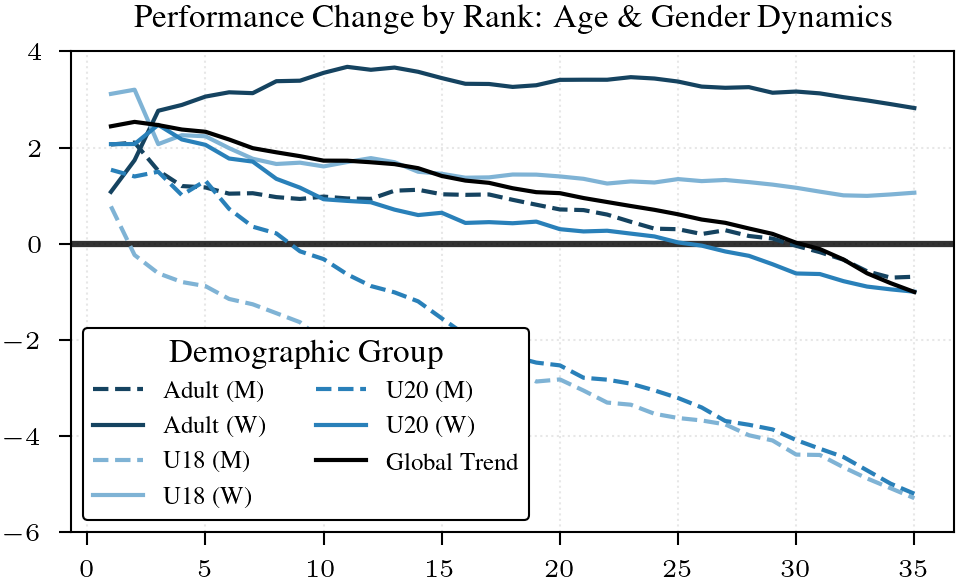

In [17]:
# import matplotlib.pyplot as plt

# 1. Setup the Plot
# plt.figure(figsize=(12, 8))

# 2. Define Age-specific colors (Consistent across genders)
# Blues/Dark tones for a professional look
age_colors = {"Adult": "#154360", "U20": "#2980b9", "U18": "#7fb3d5"}


# 4. Plot Aggregated Demographic Trends
# We use Solid for Women and Dashed for Men (or vice versa)
for (age, gender), group_df in results_ranks_age.groupby(["altersklasse", "geschlecht"]):
    color = age_colors.get(age, "grey")
    # Using different styles to distinguish gender within the same color family
    linestyle = "-" if gender == "W" else "--" 
    label = f"{age} ({gender})"
    
    plt.plot(
        group_df["rank"], 
        group_df["mean_diff_perc"], 
        color=color, 
        linestyle=linestyle, 
        # linewidth=2.8, 
        alpha=1.0, 
        label=label,
        zorder=4
    )

# 5. Global Trend (Thick Black Line)
plt.plot(
    results_ranks_all["rank"], 
    results_ranks_all["mean_diff_perc"], 
    color="black", 
    # linewidth=3, 
    linestyle="-", 
    label="Global Trend", 
    zorder=5
)

# 6. Formatting
plt.ylim(-6, 4)
plt.axhline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
plt.title("Performance Change by Rank: Age \\& Gender Dynamics")
# plt.ylabel("Performance Change (%)", fontsize=12)
# plt.xlabel("Rank (1 to 35)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.3)

# # 7. Legend - Organized in 2 columns for clarity
plt.legend(title="Demographic Group", loc='lower left', framealpha=1.0, ncol=2)

# plt.tight_layout()
plt.show()

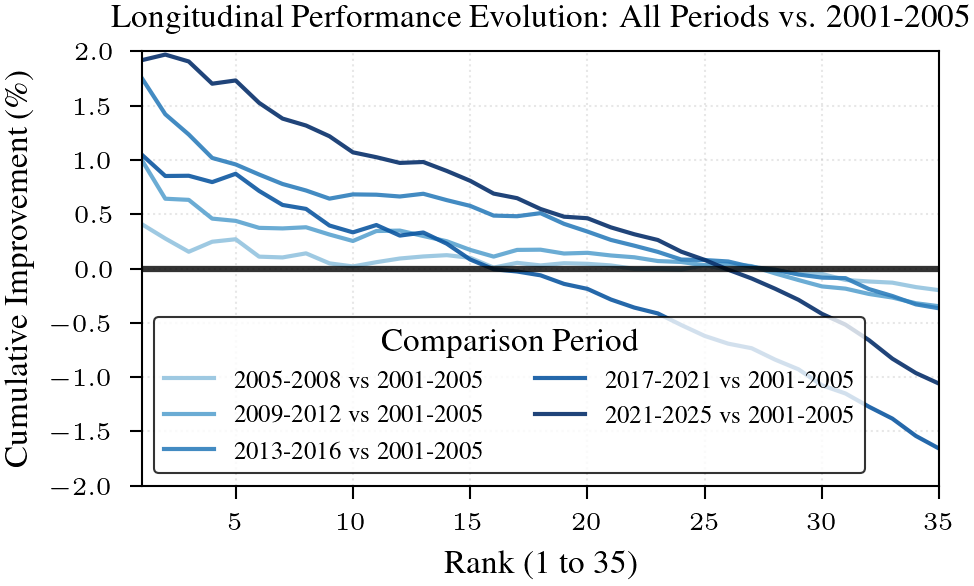

In [18]:

# 1. Define the Baseline and Comparison Periods
# Assumes 'data_all' is your main dataframe with 'jahr', 'rank', and 'iaaf_score'
def get_period(year):
    if 2001 <= year <= 2005: return "2001-2005"
    if 2005 <= year <= 2008: return "2005-2008"
    if 2009 <= year <= 2012: return "2009-2012"
    if 2013 <= year <= 2016: return "2013-2016"
    if 2017 <= year <= 2021: return "2017-2021"
    if 2021 <= year <= 2025: return "2021-2025"
    return None

data_all['period'] = data_all['jahr'].apply(get_period)
df_filtered = data_all[data_all['period'].notna()]

# 2. Calculate Mean Score per Rank per Period (Aggregating all disciplines/ages)
overall_means = df_filtered.groupby(['period', 'rank'])['iaaf_score'].mean().unstack(level=0)

# 3. Calculate % Change Relative to 2001-2005
baseline = "2001-2005"
# (Current Period - Baseline) / Baseline * 100
overall_diff = overall_means.apply(lambda x: (x - overall_means[baseline]) / overall_means[baseline] * 100)

# 4. Setup the Plot
# plt.figure(figsize=(12, 8))
plot_periods = [p for p in overall_diff.columns if p != baseline]

# Create a chronological color map (Blues or Viridis work well)
colors = plt.cm.Blues(np.linspace(0.4, 1.0, len(plot_periods)))

# 5. Plot each period vs the baseline
for i, period in enumerate(plot_periods):
    plt.plot(
        overall_diff.index, 
        overall_diff[period], 
        label=f"{period} vs {baseline}", 
        color=colors[i], 
        # linewidth=3, 
        alpha=0.9
    )

# 6. Formatting
plt.axhline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
plt.title("Longitudinal Performance Evolution: All Periods vs. 2001-2005")
plt.ylabel("Cumulative Improvement (\\%)")
plt.xlabel("Rank (1 to 35)")
plt.xlim(1, 35)
plt.ylim(-2, 2) # Adjust based on your actual data spread
plt.grid(True, linestyle=':', alpha=0.3)
plt.legend(title="Comparison Period", ncol=2)#, loc='upper right', framealpha=1.0)

# plt.tight_layout()
plt.show()